In [2]:
from comibis.utils import *
from comibis.polar import *
from comibis.spec import *

# Import raw flux data and response

6389 scw found
['150-200' '200-210' '210-220' '220-230' '230-240' '240-250' '250-260'
 '260-270' '270-280' '280-290' '290-300' '300-350' '350-400' '400-450'
 '450-500' '500-600' '600-700' '700-800' '800-1000' '1000-1500'
 '1500-2000' '2000-2500' '2500-3000']


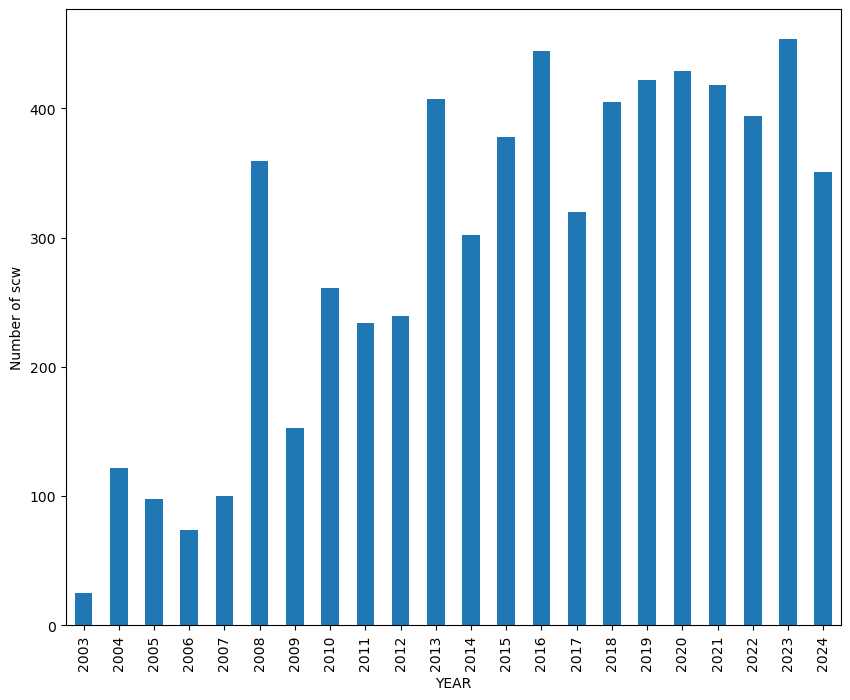

In [3]:
src ='crab' # short-hand name of source
scw_file_name_list = ['all'] # several df can be combined (energy/pola binnings need to match)

resp_dir= 'compton_responses'
saved_pola_dir = 'saved_pola_df'
spicorr_file = 'compcorr_2YEAR_5deg_best.csv' # correction file with alpha/beta paramaters

fig, ax= plt.subplots(1,1,figsize=(10,8))
df_spicorr = pd.read_csv(f'{resp_dir}/{spicorr_file}', index_col=0)
df_pola_scw, all_band_names = charge_df(src, scw_file_name_list, saved_pola_dir, df_spicorr)
df_spicorr_rbn, rbn_compcorr_matrix = rebin_compcorr(df_spicorr, all_band_names)

# Polarization

## Select the data, compute polarigrams

In [4]:
##### Selections #####

date_type, start_date, end_date= 'ISOT', '2004-01-01', '2017-01-01'
rev_list = None # to select from a list of revolutions
angle_max = 5. # max off-axis angle

df_pola_scw_sel = scw_selection(df_pola_scw, angle_max=angle_max, rev_list=rev_list, start_date=start_date, end_date=end_date, date_type=date_type)

#### Choose correction ####
compnorm , spicorr = 'auto', 'auto' # normal correction (standard)
# compnorm, spicorr = 1., 'auto' # without alpha parameters

#### Build polarigrams ####
all_polarigrams = Polarigram(df_pola_scw_sel, all_band_names, angle_max) # initialize polarigrams
all_polarigrams.import_prf(pulsefrac_dir=resp_dir, pulsefrac_file='comps-prf-2.txt') # import polarization response
print(f'{len(df_pola_scw_sel.SCW.unique())} scw selected (avg off-axis angle = {df_pola_scw_sel.ANGLE.mean():.1f}°)')
print(f'Exposure = {all_polarigrams.expo/1000:.0f} ks')
all_polarigrams.make_polar(spicorr, compnorm, df_spicorr_rbn) # compute all polarigrams

2211 scw selected (avg off-axis angle = 3.3°)
Exposure = 5046 ks


## Energy evolution

Show polarization (PA, PF) as a function of energy.

energy bands: can be set to 'all' to make a polarigram of each energy band, without combining them, or a list of energy bands.

pa_ref: can be chosen between PA_ref90 (PAs between [0, 180]°) or PA_ref0 (PAs between [-90, 90]°).

errortype: 'margin' is recommended as it uses marginalized posterior, otherwise 'like' will find uncertainties from likelihood

Other parameters should be kept at default values.

Polarized flux in 200 - 300 keV band
reduced chi2: pola=0.98, no pola=8.65
initial PF = 38.46 %
total flux = 1.3e-01 ± 4.6e-03 ct/s
SNR = 70.2 p-value = 1.6e-09 (6.0-sigma)
PA = 134.1 ± 4.5 °
PF = 38.0 (+6.0/-6.1) %


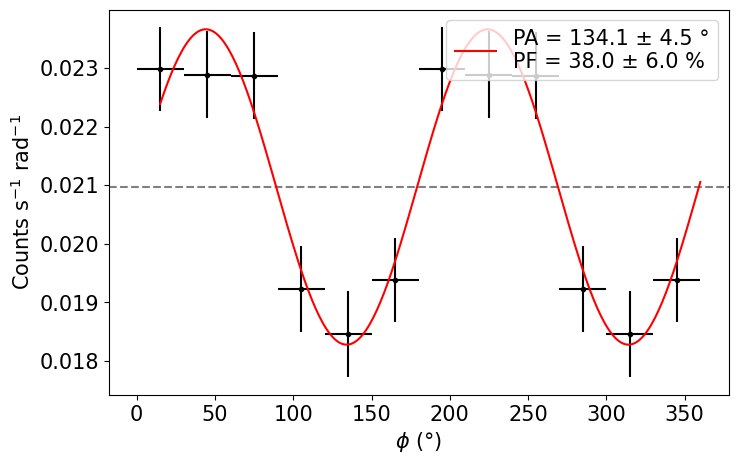

Polarized flux in 300 - 400 keV band
reduced chi2: pola=0.31, no pola=2.83
initial PF = 47.81 %
total flux = 1.2e-01 ± 7.5e-03 ct/s
SNR = 38.4 p-value = 1.3e-03 (3.2-sigma)
PA = 137.7 ± 8.3 °
PF = 45.9 (+13.3/-13.5) %


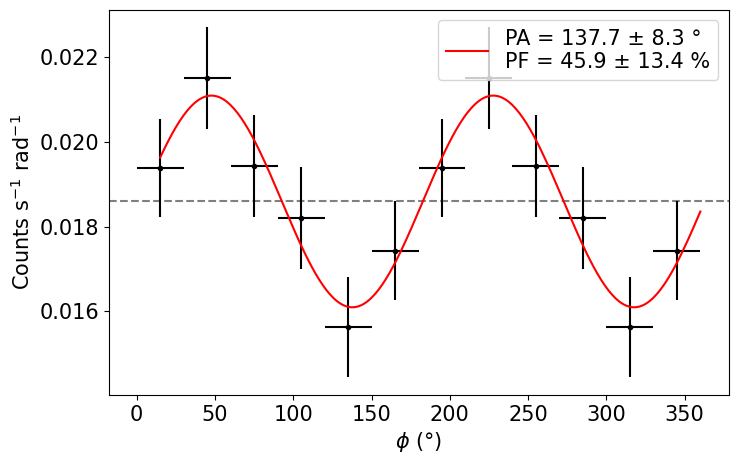

Polarized flux in 400 - 1000 keV band
reduced chi2: pola=1.62, no pola=2.94
initial PF = 59.37 %
total flux = 1.8e-01 ± 1.3e-02 ct/s
SNR = 33.9 p-value = 7.4e-03 (2.7-sigma)
PA = 125.9 ± 10.1 °
PF = 56.1 (+19.2/-19.6) %


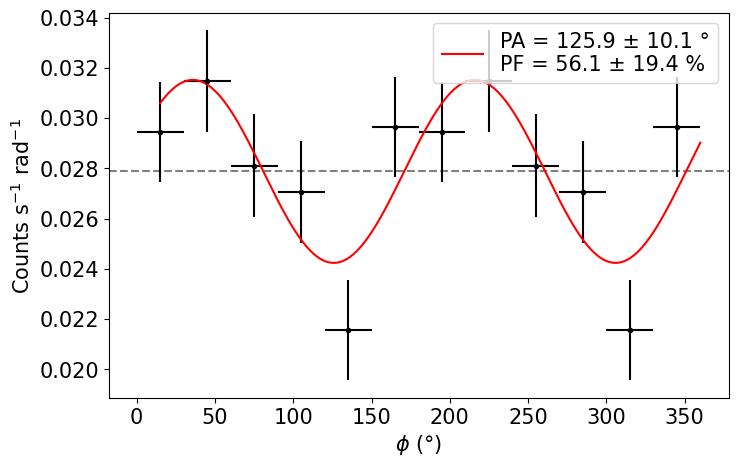

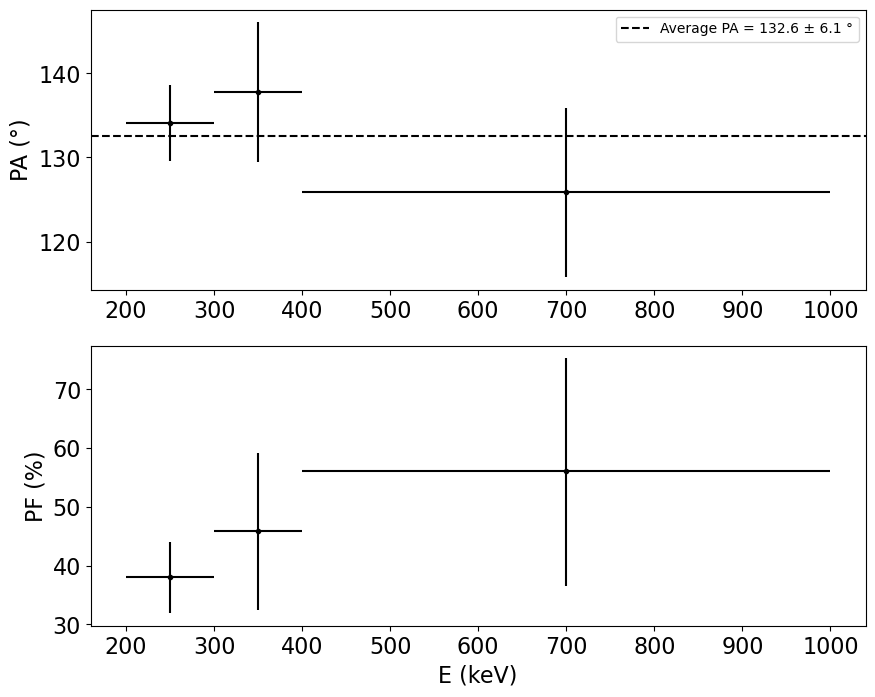

In [5]:
energy_bands = [ '200-300','300-400','400-1000'] # energy bands in keV
# energy_bands = 'all'
pa_ref = 'PA_ref90' # reference angle
p_det = .01 # threshold for polarization detection, usually 1%
p_lim = .1 # probability to use for upper-limits, usually 10% (i.e. 90% CI)
SNR_threshold = 13. # SNR threshold for flux detection
verbose = 0
errortype = 'margin'

all_polarigrams.pola_espectrum(energy_bands, pa_ref, SNR_threshold, p_det, p_lim, 1, verbose, errortype)
all_polarigrams.plot_pola_espectrum(plot_scale='lin', plot_percent=True)

## Single polarigram

to analyze a single energy band

Polarized flux in 200 - 250 keV band
reduced chi2: pola=1.02, no pola=4.68
initial PF = 31.89 %
total flux = 5.8e-02 ± 2.4e-03 ct/s
SNR = 58.6 p-value = 3.5e-05 (4.1-sigma)
PA = 137.0 ± 6.5 °
PF = 31.1 (+7.0/-7.2) %


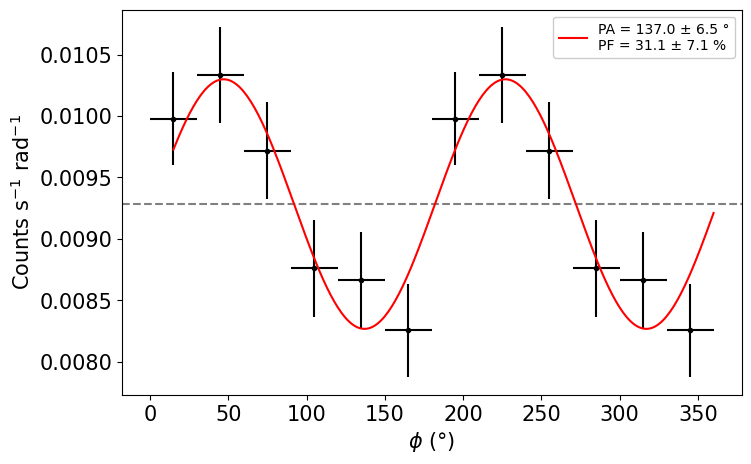

In [6]:
Emin, Emax = 200, 250

pa_ref='PA_ref90'
errortype = 'margin'
p_det = .01
p_lim = .01
SNR_threshold = 13.

bands = all_polarigrams.combine_bands(Emin, Emax)
pola_dico, ax = all_polarigrams.fit_pola(bands, p_det, p_lim, folded=1, weighted=1, pa_ref=pa_ref, verbose=True, article=0, plot_0=True, errortype=errortype)
ax.legend(framealpha=1., loc='upper right')

show the 2D contours of the delta negative log-likelihood

(0.0, 100.0)

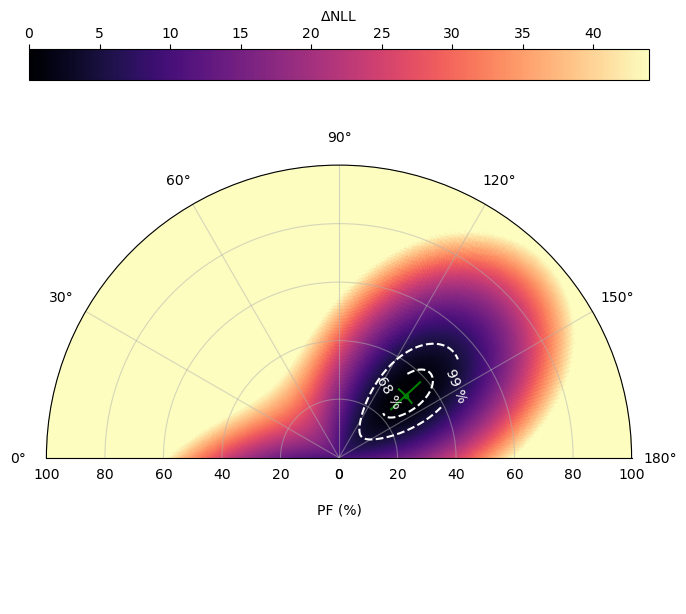

In [7]:
ax = all_polarigrams.plot_nll(n_grid = 200, list_p_contour=[.68, .99], cmap='magma', vmax_fact=1., polar_plot=True, only_contour=0)
ax.set_rlim(0,100)

## Time evolution

The data set can be cut in different groups of revolutions (REV), years, or science windows (scw)

The groups can be given directly in a dictionary (ex: crab_year_groups), or as a number. In that case, the groups will be created chronologicaly with the same number of elements (year, revs, ...).

Results are recorded in df_param_select and plotted with time.

22 unique YEAR found: [2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024]
6 select list found:[[2004, 2005, 2006, 2007, 2008, 2009], [2010, 2011, 2012, 2013, 2014], [2015, 2016], [2017, 2018], [2019, 2020, 2021, 2022], [2023, 2024]]


****** ------------------------------------------------------------------------- ******

Polarigram of YEAR 2004 - 2009
Exposure = 1394 ks
Start = MJD 53069.810241 Stop = MJD 55072.534304
Average SpiCorr = 0.724
['200-210', '210-220', '220-230', '230-240', '240-250', '250-260', '260-270', '270-280', '280-290', '290-300', '300-350', '350-400']
Polarized flux in 200 - 400 keV band
reduced chi2: pola=1.62, no pola=3.35
initial PF = 52.46 %
total flux = 2.5e-01 ± 1.9e-02 ct/s
SNR = 32.2 p-value = 2.4e-03 (3.0-sigma)
PA = 140.9 ± 8.8 °
PF = 50.1 (+15.5/-15.6) %


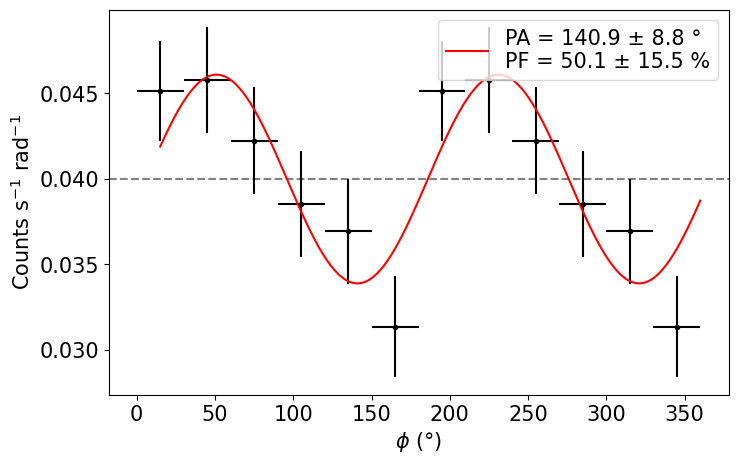



****** ------------------------------------------------------------------------- ******

Polarigram of YEAR 2010 - 2014
Exposure = 2032 ks
Start = MJD 55258.770609 Stop = MJD 56952.113972
Average SpiCorr = 0.696
['200-210', '210-220', '220-230', '230-240', '240-250', '250-260', '260-270', '270-280', '280-290', '290-300', '300-350', '350-400']
Polarized flux in 200 - 400 keV band
reduced chi2: pola=1.29, no pola=3.10
initial PF = 36.46 %
total flux = 2.5e-01 ± 1.3e-02 ct/s
SNR = 45.6 p-value = 2.9e-03 (3.0-sigma)
PA = 133.8 ± 9.0 °
PF = 34.8 (+10.8/-11.1) %


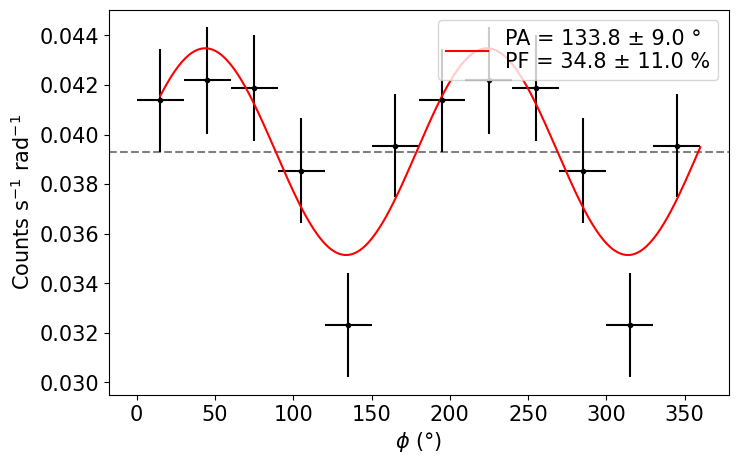



****** ------------------------------------------------------------------------- ******

Polarigram of YEAR 2015 - 2016
Exposure = 1618 ks
Start = MJD 57068.571139 Stop = MJD 57675.334902
Average SpiCorr = 0.711
['200-210', '210-220', '220-230', '230-240', '240-250', '250-260', '260-270', '270-280', '280-290', '290-300', '300-350', '350-400']
Polarized flux in 200 - 400 keV band
reduced chi2: pola=0.42, no pola=4.37
initial PF = 50.92 %
total flux = 2.5e-01 ± 1.4e-02 ct/s
SNR = 43.4 p-value = 3.3e-05 (4.2-sigma)
PA = 133.1 ± 6.5 °
PF = 49.6 (+11.3/-11.4) %


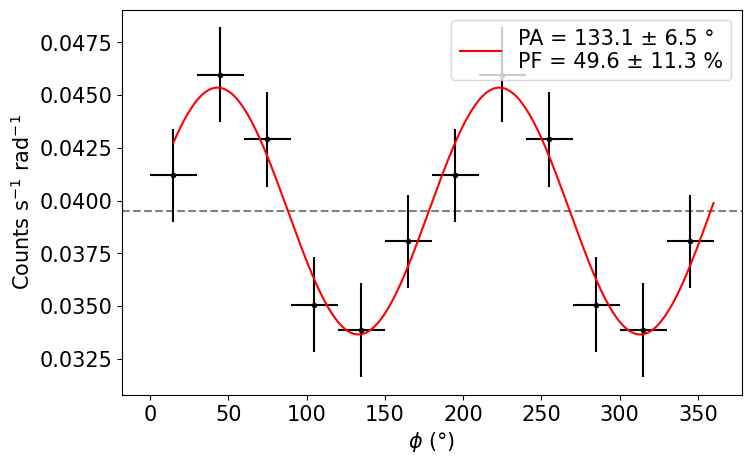



****** ------------------------------------------------------------------------- ******

Polarigram of YEAR 2017 - 2018
Exposure = 1412 ks
Start = MJD 57794.597163 Stop = MJD 58404.044227
Average SpiCorr = 0.787
['200-210', '210-220', '220-230', '230-240', '240-250', '250-260', '260-270', '270-280', '280-290', '290-300', '300-350', '350-400']
Polarized flux in 200 - 400 keV band
reduced chi2: pola=0.64, no pola=2.89
initial PF = 60.53 %
total flux = 2.5e-01 ± 2.1e-02 ct/s
SNR = 28.5 p-value = 1.8e-03 (3.1-sigma)
PA = 128.6 ± 8.6 °
PF = 58.0 (+17.2/-17.4) %


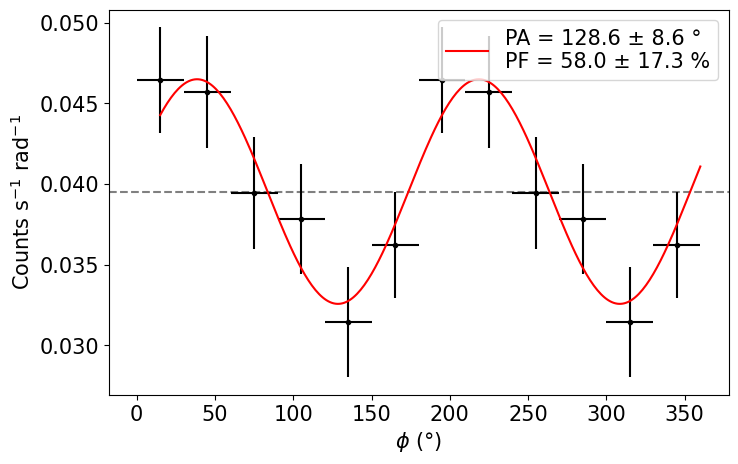



****** ------------------------------------------------------------------------- ******

Polarigram of YEAR 2019 - 2022
Exposure = 3026 ks
Start = MJD 58531.160923 Stop = MJD 59880.522355
Average SpiCorr = 0.818
['200-210', '210-220', '220-230', '230-240', '240-250', '250-260', '260-270', '270-280', '280-290', '290-300', '300-350', '350-400']
Polarized flux in 200 - 400 keV band
reduced chi2: pola=0.25, no pola=2.13
initial PF = 45.13 %
total flux = 2.5e-01 ± 1.8e-02 ct/s
SNR = 34.2 p-value = 6.5e-03 (2.7-sigma)
PA = 142.3 ± 9.8 °
PF = 42.7 (+14.6/-14.9) %


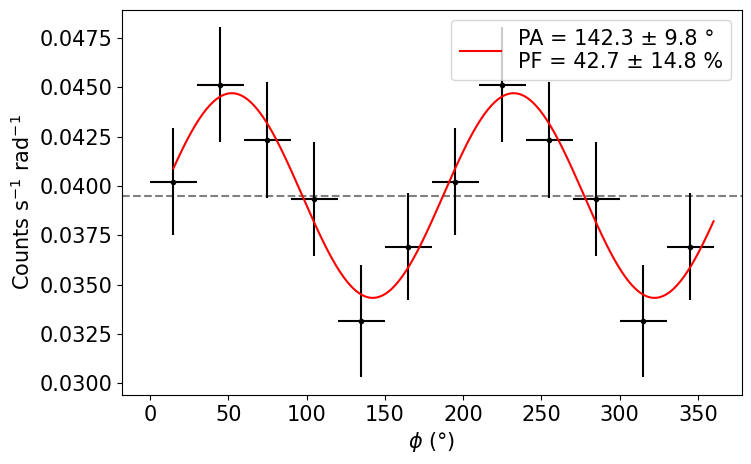



****** ------------------------------------------------------------------------- ******

Polarigram of YEAR 2023 - 2024
Exposure = 1412 ks
Start = MJD 59989.427569 Stop = MJD 60594.577823
Average SpiCorr = 0.778
['200-210', '210-220', '220-230', '230-240', '240-250', '250-260', '260-270', '270-280', '280-290', '290-300', '300-350', '350-400']
Polarized flux in 200 - 400 keV band
reduced chi2: pola=1.71, no pola=3.46
initial PF = 53.58 %
total flux = 2.5e-01 ± 1.9e-02 ct/s
SNR = 31.7 p-value = 2.2e-03 (3.1-sigma)
PA = 124.2 ± 8.7 °
PF = 51.2 (+15.6/-15.8) %


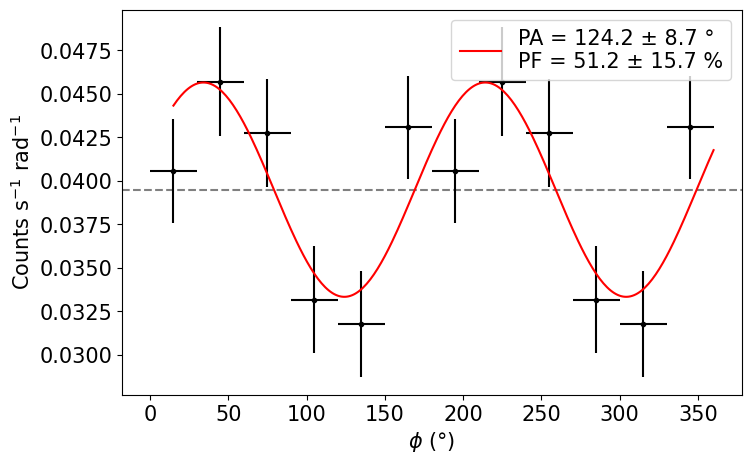

,SNR,PA,PA_err,uplim,EXPO,PF_pct,PF_pct_err,p_higher
0,32.154869,140.949937,8.803761,0,1.394745e+06,50.127501,15.542155,0.002438
1,45.578670,133.758241,8.983797,0,2.032375e+06,34.783348,10.981110,0.002894
2,43.361500,133.148250,6.499300,0,1.618841e+06,49.638496,11.319113,0.000033
3,28.513637,128.553365,8.587718,0,1.412483e+06,57.967580,17.308173,0.001831
4,34.169924,142.282070,9.847970,0,3.026651e+06,42.688427,14.780648,0.006517
5,31.708646,124.173766,8.731746,0,1.412410e+06,51.236512,15.738657,0.002225


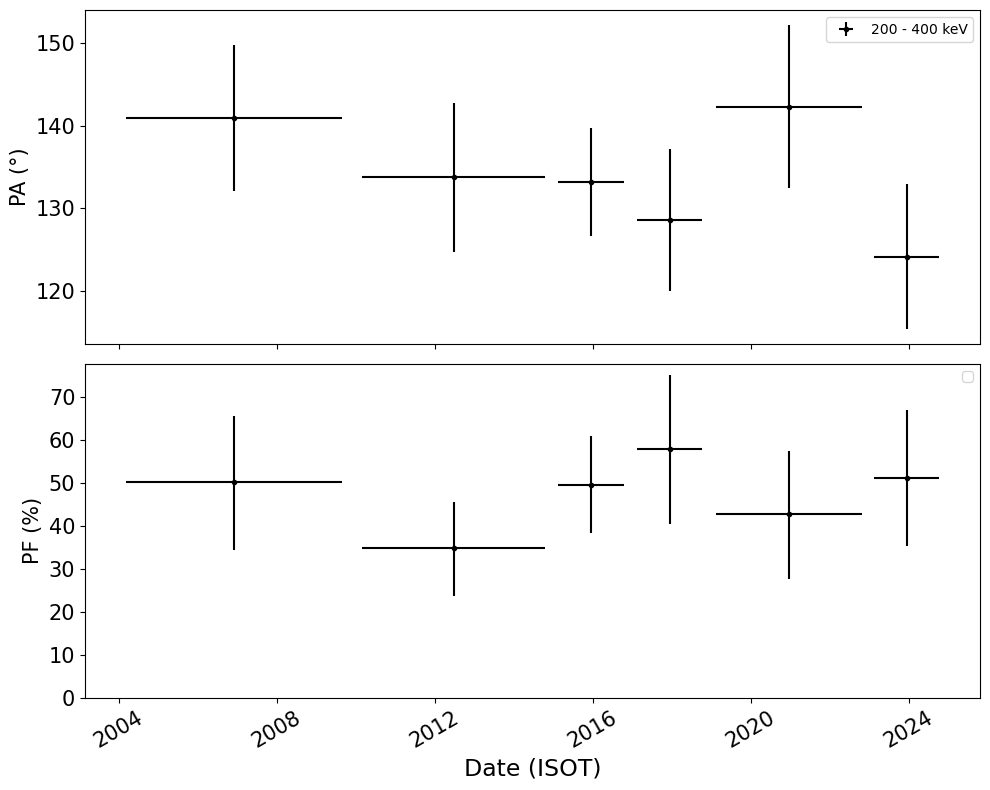

In [8]:
crab_year_groups = {'1':[2004,2005,2006,2007,2008,2009], '2':[2010,2011,2012,2013,2014],'3':[2015,2016],
          '4':[2017,2018], '5':[2019,2020,2021,2022], '6':[2023,2024]}

all_src_dico={ # 'src name': [energy range, group list dictionary, reference angle, states (optional)]
              'crab':[[200, 400], crab_year_groups, 'PA_ref90', None],
              # 'crab':[[200, 400], 31, 'PA_ref90', None] # if no group list
              }


##### Data Selection #####

src_name = 'crab'
column_name = 'YEAR' # group by YEAR, REV or SCW
date_type = 'ISOT' # or MJD
angle_max = 5.
# other informations to plot

##### Correction and stat thresholds #####

compnorm , spicorr = 'auto',  'auto'
errortype='margin'
p_det = 0.01
p_lim = 0.01
SNR_threshold=13.
with_proba = 0 # show p-value
with_expo = 0 # show exposure
verbose=1

##### Make time evolution polarization #####

grp = all_src_dico[src_name][1]
states_mjd = all_src_dico[src_name][3]

df_pola_scw_sel = df_pola_scw[df_pola_scw.ISOT > '2003-06-01'] # default start date
all_unique = np.sort(df_pola_scw_sel[column_name].unique())[:]
print(f'{len(all_unique)} unique {column_name} found: {all_unique}')

if type(grp) == int:
  select_list, select_names= [list(all_unique)[i*grp:(i+1)*grp] for i in range(len(all_unique)//grp+(len(all_unique)%grp>0))], None
else: select_list, select_names= list(grp.values()), list(grp.keys())
print(f'{len(select_list)} select list found:{select_list}')
# compute polarization for each period
df_param_select = pola_select(df_pola_scw_sel, all_src_dico[src_name], all_band_names, angle_max, column_name, select_list,
                             spicorr, compnorm, .14, 'comps-prf-2.txt', df_spicorr_rbn, resp_dir,errortype, SNR_threshold, 1, p_det,p_lim, verbose)
# plot polarization with time
axes = plot_pola_select(df_param_select, all_src_dico[src_name], plot_percent=True, with_proba=with_proba, with_snr=0,
                        with_expo=with_expo, jet_angle=None, date_type='ISOT')
df_param_select[['SNR', 'PA',	'PA_err', 'uplim','EXPO','PF_pct',	'PF_pct_err','p_higher']]

# Spectrum

## Select data, build spectrum

In [9]:
date_type, start_date, end_date= 'ISOT', '2010-01-01', '2020-01-01'
rev_list = None # to select from a list of revolutions
angle_max = 5. # max off-axis angle
spec_sys_error = .05 # systematic error
spicorr = 'auto' # beta correction factor (alpha should be 1 for spectrum)

df_pola_scw_sel = scw_selection(df_pola_scw, angle_max=angle_max, rev_list=rev_list, start_date=start_date, end_date=end_date, date_type=date_type)
comp_response = Response(resp_dir, 'COMP-SEBD-MOD', 'COMP-SRMF-RSP')
comp_spectrum = ComptonSpectrum(df_pola_scw_sel, all_band_names, spec_sys_error, angle_max)
comp_spectrum.make_rate(spicorr=spicorr, compnorm=1, df_spicorr_rbn=df_spicorr_rbn)
comp_response.make_rbn_mat(comp_spectrum.E_bounds_rbn)

print(f'{len(df_pola_scw_sel.SCW.unique())} scw selected (avg off-axis angle = {df_pola_scw_sel.ANGLE.mean():.1f}°)')
print(f'Exposure = {comp_spectrum.expo/1000:.0f} ks')
print(f'Start: {comp_spectrum.ISOT_START} End: {comp_spectrum.ISOT_END}')

2407 scw selected (avg off-axis angle = 3.4°)
Exposure = 5748 ks
Start: 2010-03-03 18:29:40.618000 End: 2019-10-14 20:41:15.072000


## Fit spectrum

The spec_type is used to change the y-axis units.

The 'powerlaw_erg' model is a power-law for which the normalization is defined as a integrated flux between e1 and e2; this is more interpretable than 'K' and gives the uncertainties directly.

name,value,standard error,relative error,initial value,min,max,vary
K,6.6476e-09,2.4993e-10,(3.76%),1e-09,-inf,inf,True
gamma,2.31223968,0.11320000,(4.90%),2.0,1.00000000,inf,True
e1,350.000000,0.00000000,(0.00%),350.0,-inf,inf,0
e2,1000.00000,0.00000000,(0.00%),1000.0,-inf,inf,0


Red Chi2 = 0.44 (3.95 / 9 dof)


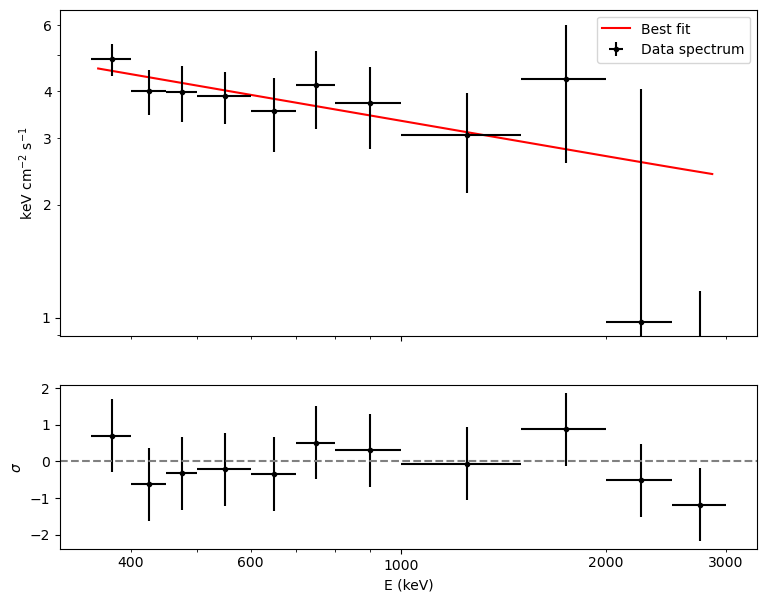

In [10]:
e_min_fit, e_max_fit = 350., 3000. # energy bounds to use for fit
spec_type = 'EEFLUX' # possible: 'RATE', 'FLUX', 'EFLUX' , 'EEFLUX' , 'ERG'
res_type = 'RES' #'REDCHI2'
rebin_fact_model = 30 # factor to re-bin the model spectrum if using RATE

model_name, lmfit_params ='powerlaw_erg', lm.create_params(K={'value': 1e-9}, gamma={'value': 2., 'min':1.},
                                                           e1={'value': 350, 'vary':0}, e2={'value': 1000, 'vary':0})
# model_name, lmfit_params ='powerlaw', lm.create_params(K={'value': 15., 'vary':1}, gamma={'value': 2., 'min':0.,'vary':1})
# model_name, lmfit_params ='cutoffpl', lm.create_params(K={'value': 15, 'min':0.}, alpha={'value': 1.6, 'min':1.}, beta={'value': 150, 'vary':1} )

model = Model(model_name)
result, minner = fit_spec(comp_spectrum, model, comp_response, lmfit_params, e_min_fit, e_max_fit)
display(result.params)
print(f'Red Chi2 = {result.redchi:.2f} ({result.chisqr:.2f} / {result.nfree} dof)')
axes = plot_spec_model(comp_spectrum, model, e_min_fit, e_max_fit, spec_type, 'RES', rebin_fact_model,'log')
